# Brazilian Digital Identity on Instagram: Content Analysis of User-Generated Comments

This notebook operationalizes the content-analysis methodology described in the research proposal (`Método - TCC.docx`). The study applies **thematic content analysis** (Bardin, 2016) to user-generated comments posted on three international Instagram profiles that mobilized Brazilian audiences. The analytical framework follows a multi-axis coding scheme: **theme**, **character** (affective/cognitive), **tone** (positive/negative/neutral), **stakeholder type**, and **non-verbal elements** (emojis/hashtags).

The research questions and propositions (P1–P4) are tested quantitatively on the merged human-reviewed dataset `outputs/classified_comments_human.csv`. Because the collected corpus is larger than the originally planned sample of 600 top-liked comments, the notebook reports results for the full corpus and explicitly notes this methodological adaptation.

## Key references

- Bardin, L. (2016). *Análise de conteúdo* (4th ed.). Edições 70.
- Braun, V., & Clarke, V. (2006). [Using thematic analysis in psychology](https://doi.org/10.1191/1478088706qp063oa). *Qualitative Research in Psychology*, 3(2), 77–101.
- Cohen, J. (1960). [A coefficient of agreement for nominal scales](https://doi.org/10.1177/001316446002000104). *Educational and Psychological Measurement*, 20(1), 37–46.
- Cramér, H. (1946). *Mathematical methods of statistics*. Princeton University Press.
- Gilardi, F., Alizadeh, M., & Kubli, M. (2023). [ChatGPT outperforms crowd workers for text-annotation tasks](https://doi.org/10.1073/pnas.2305016120). *PNAS*, 120(30), e2305016120.
- Kozinets, R. V. (2014). *Netnography: Redefined* (2nd ed.). SAGE.
- Landis, J. R., & Koch, G. G. (1977). [The measurement of observer agreement for categorical data](https://doi.org/10.2307/2529310). *Biometrics*, 33(1), 159–174.
- Pang, B., & Lee, L. (2008). [Opinion mining and sentiment analysis](https://doi.org/10.1561/1500000011). *Foundations and Trends in Information Retrieval*, 2(1–2), 1–135.
- Tajfel, H., & Turner, J. C. (1979). [An integrative theory of intergroup conflict](https://doi.org/10.4324/9780203505984-16). In W. G. Austin & S. Worchel (Eds.), *The social psychology of intergroup relations* (pp. 33–47). Brooks/Cole.
- Dinnie, K. (2016). *Nation branding: Concepts, issues, practice* (2nd ed.). Routledge.

In [28]:
# Setup: imports and visualization defaults
import ast
import re
import string
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Load the merged human-reviewed dataset

The file `outputs/classified_comments_human.csv` merges machine-generated codes with human adjudication for comments that passed the κ-based human-review gate (Cohen, 1960; Landis & Koch, 1977; Gilardi et al., 2023).

In [29]:
df = pd.read_csv("outputs/classified_comments_human.csv", low_memory=False)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print("\nCases:")
print(df["case"].value_counts())
display(df.head(2))

Rows: 17,287
Columns: 62

Cases:
case
Bruno_Mars         8100
Fernanda_Torres    6619
CR7                2568
Name: count, dtype: int64


,case,comment,likes_raw,likes,date_iso,hash_id,comment_norm,comment_length,emojis_list,hashtags_list,...,theme_C3_human,theme_C4_human,theme_C5_human,theme_NA_human,character_human,tone_human,human_notes,reviewed_by,reviewed_at,human_reviewed
0,Bruno_Mars,😍🇧🇷😂,0,0,2025-10-03 17:13:38+00:00,BRUNO_MARS_0001,😍🇧🇷😂,4,"['😍', '😂', '🇧🇷']",[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Bruno_Mars,😍🇧🇷📍,0,0,2025-10-03 17:13:44+00:00,BRUNO_MARS_0002,😍🇧🇷📍,4,"['😍', '📍', '🇧🇷']",[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. Pre-analysis: corpus overview and methodological note

Bardin (2016) defines content analysis as a set of communication-analysis techniques that apply systematic and objective procedures to describe message content. The pre-analysis phase organizes the material and performs a first contact with the data.

**Methodological adaptation:** The original proposal planned to analyze 200 top-liked comments per case (600 total). The current dataset contains all collected comments for each case. We therefore report frequencies and percentages over the full available corpus and flag this divergence in the interpretation.

In [30]:
# Integrity checks
assert df["hash_id"].is_unique, "hash_id must be unique"
print(f"hash_id unique: {df['hash_id'].is_unique}")

key_fields = ["case", "comment_anon", "character", "tone", "classification_source"]
print("\nMissing values in key fields:")
print(df[key_fields].isna().sum())

print("\nClassification source:")
print(df["classification_source"].value_counts())
print("\nHuman review coverage:")
print(df["human_reviewed"].value_counts())

hash_id unique: True

Missing values in key fields:
case                     0
comment_anon             0
character                0
tone                     0
classification_source    0
dtype: int64

Classification source:
classification_source
rule            11927
llm_agreed       3820
llm_reviewer     1352
human             188
Name: count, dtype: int64

Human review coverage:
human_reviewed
False    17099
True       188
Name: count, dtype: int64


In [31]:
# Volume and engagement per case
case_counts = df["case"].value_counts().reset_index()
case_counts.columns = ["case", "n_comments"]
case_counts["pct"] = (case_counts["n_comments"] / case_counts["n_comments"].sum() * 100).round(1)
print(case_counts)

likes_stats = (
    df.groupby("case")["likes"].describe()[["count", "mean", "50%", "75%", "max"]].round(2)
)
print("\nLikes statistics per case:")
print(likes_stats)

              case  n_comments   pct
0       Bruno_Mars        8100  46.9
1  Fernanda_Torres        6619  38.3
2              CR7        2568  14.9



Likes statistics per case:
                  count  mean  50%  75%    max
case                                          
Bruno_Mars       8100.0  1.34  1.0  2.0   18.0
CR7              2568.0  1.62  0.0  1.0  330.0
Fernanda_Torres  6619.0  1.65  1.0  2.0   70.0


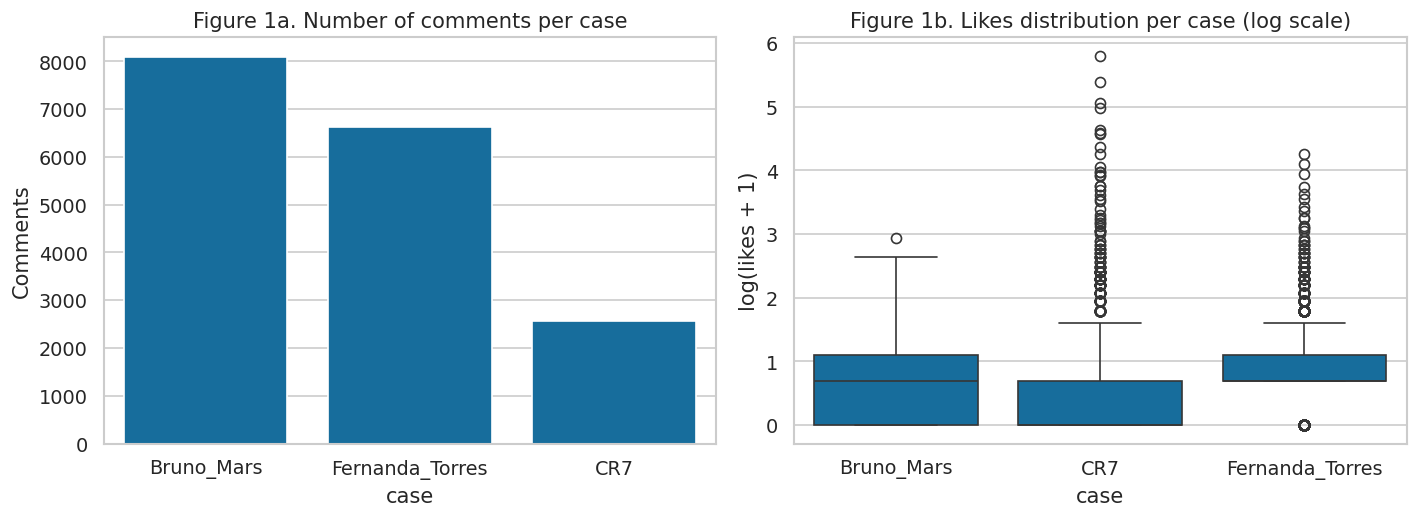

In [32]:
# Figure 1: comments and likes by case
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=case_counts, x="case", y="n_comments", ax=axes[0])
axes[0].set_title("Figure 1a. Number of comments per case")
axes[0].set_ylabel("Comments")

df["log_likes"] = np.log1p(df["likes"])
sns.boxplot(data=df, x="case", y="log_likes", ax=axes[1])
axes[1].set_title("Figure 1b. Likes distribution per case (log scale)")
axes[1].set_ylabel("log(likes + 1)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_corpus_overview.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Thematic content analysis

The central axis classifies each comment into one or more themes. Categories were developed through a hybrid deductive-inductive process (Bardin, 2016; Braun & Clarke, 2006):

- **C1 — Nacionalismo/Orgulho**: expressions of national pride or exaltation of Brazilian symbols.
- **C2 — Humor/Sátira/Meme**: jokes, irony, sarcasm, or meme references.
- **C3 — Conflito/Rivalidade**: disputes or rivalry with foreigners, brands, or figures.
- **C4 — Validação/Afeto pelo Estrangeiro**: appreciation or gratitude toward international attention.
- **C5 — Apropriação do Espaço Digital**: off-topic Portuguese comments marking Brazilian presence.
- **N.A.**: neutral, descriptive, or non-classifiable comments.

Because themes are not mutually exclusive, we report presence counts and within-case percentages.

In [33]:
THEME_CODES = ["C1", "C2", "C3", "C4", "C5"]
THEME_LABELS = {
    "C1": "Nacionalismo/Orgulho",
    "C2": "Humor/Sátira/Meme",
    "C3": "Conflito/Rivalidade",
    "C4": "Validação/Afeto pelo Estrangeiro",
    "C5": "Apropriação do Espaço Digital",
}
theme_cols = [f"theme_{c}" for c in THEME_CODES] + ["theme_NA"]

theme_counts = df.groupby("case")[theme_cols].sum().astype(int)
# Keep Series (not .to_dict) so build_final_table can use .index
case_totals = df["case"].value_counts()
# Vectorized division yields float64 (avoids int64 .loc upcast TypeError)
theme_pct = (theme_counts.div(case_totals, axis=0) * 100).round(1)

print("Theme counts per case:")
display(theme_counts)
print("\nTheme percentages per case:")
display(theme_pct)

Theme counts per case:


,theme_C1,theme_C2,theme_C3,theme_C4,theme_C5,theme_NA
case,,,,,,
Bruno_Mars,127,40,3,5364,6657,28
CR7,942,6,21,1632,71,128
Fernanda_Torres,6519,30,29,13,304,46



Theme percentages per case:


,theme_C1,theme_C2,theme_C3,theme_C4,theme_C5,theme_NA
case,,,,,,
Bruno_Mars,1.6,0.5,0.0,66.2,82.2,0.3
CR7,36.7,0.2,0.8,63.6,2.8,5.0
Fernanda_Torres,98.5,0.5,0.4,0.2,4.6,0.7


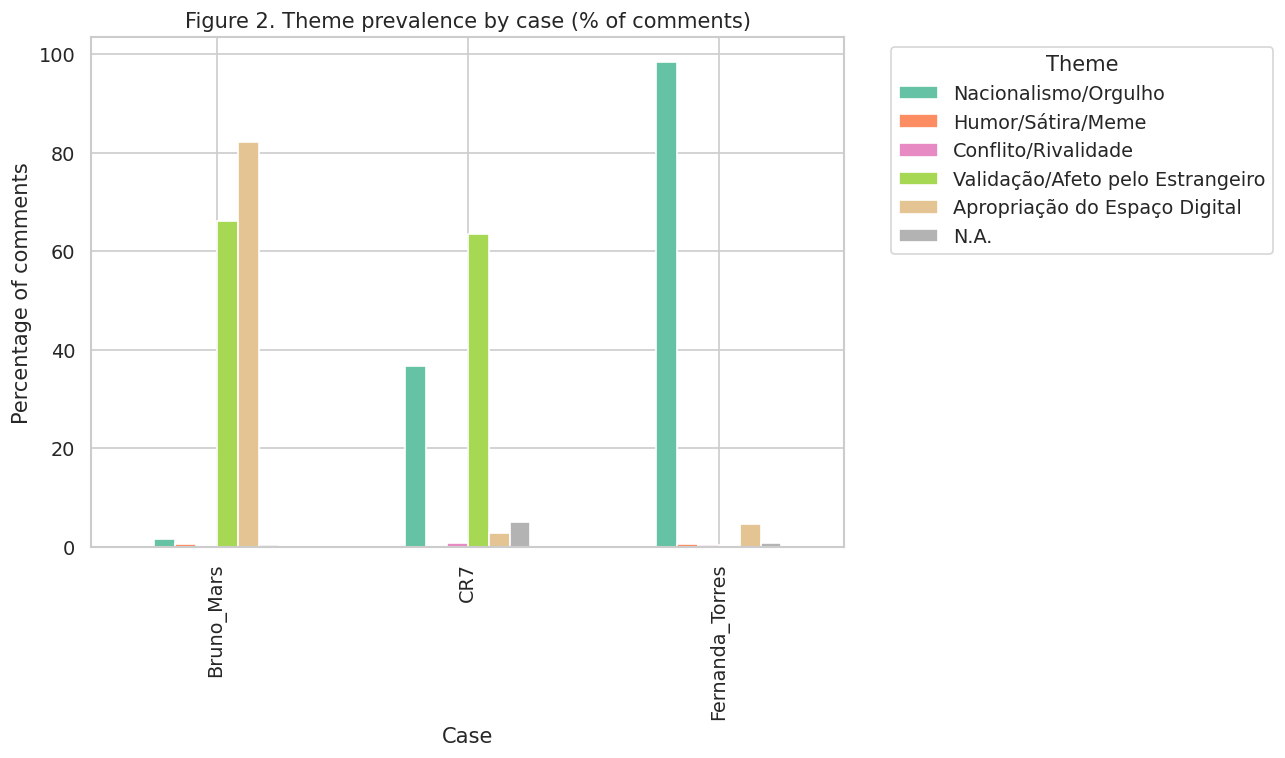

In [34]:
# Figure 2: grouped bars (themes are multi-label; stacked bars exceed 100%)
theme_pct_plot = theme_pct.rename(columns={f"theme_{c}": THEME_LABELS[c] for c in THEME_CODES})
theme_pct_plot = theme_pct_plot.rename(columns={"theme_NA": "N.A."})

ax = theme_pct_plot.plot(kind="bar", stacked=False, figsize=(11, 6.5), colormap="Set2")
ax.set_title("Figure 2. Theme prevalence by case (% of comments)")
ax.set_ylabel("Percentage of comments")
ax.set_xlabel("Case")
ax.legend(title="Theme", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_theme_distribution_grouped.png", dpi=300, bbox_inches="tight")
plt.show()

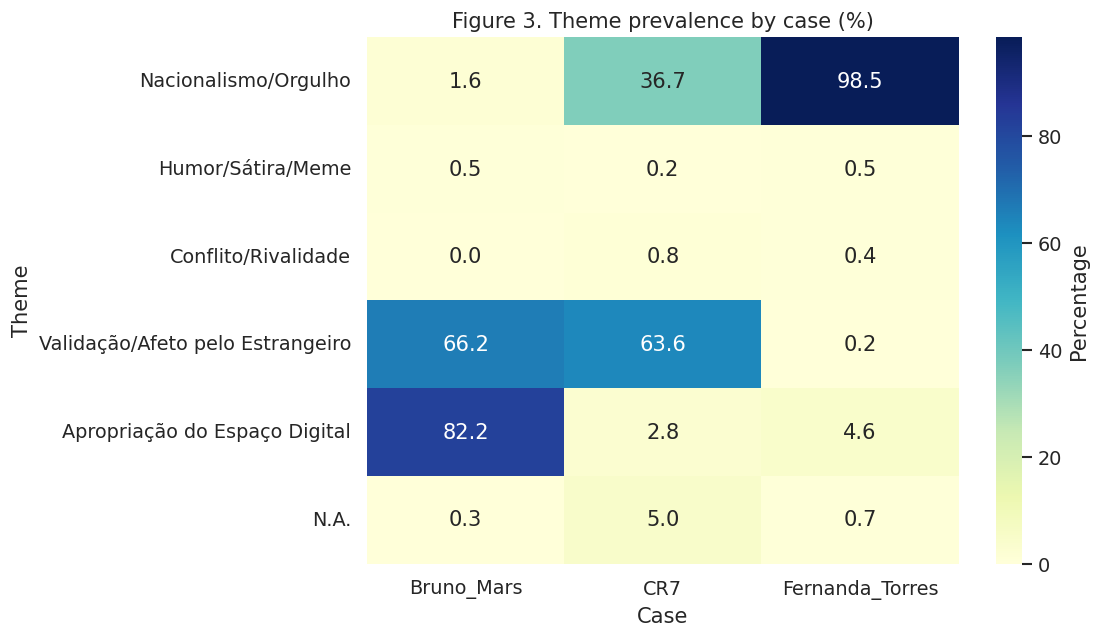

In [35]:
# Figure 3: heatmap
plt.figure(figsize=(9.5, 5.5))
sns.heatmap(
    theme_pct_plot.T,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage"},
)
plt.title("Figure 3. Theme prevalence by case (%)")
plt.ylabel("Theme")
plt.xlabel("Case")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_theme_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Character analysis: affective vs. cognitive

Following Garay (2019), each comment is classified as predominantly **Afetivo** (expressing emotions) or **Cognitivo** (communicating information and facts).

In [36]:
char_crosstab = pd.crosstab(df["character"], df["case"], margins=True, margins_name="Total")
char_pct = pd.crosstab(df["character"], df["case"], normalize="columns") * 100
print("Character counts:")
display(char_crosstab)
print("\nCharacter percentages by case:")
display(char_pct.round(1))

Character counts:


case,Bruno_Mars,CR7,Fernanda_Torres,Total
character,,,,
Afetivo,7961,2489,6580,17030
Cognitivo,139,79,39,257
Total,8100,2568,6619,17287



Character percentages by case:


case,Bruno_Mars,CR7,Fernanda_Torres
character,,,
Afetivo,98.3,96.9,99.4
Cognitivo,1.7,3.1,0.6


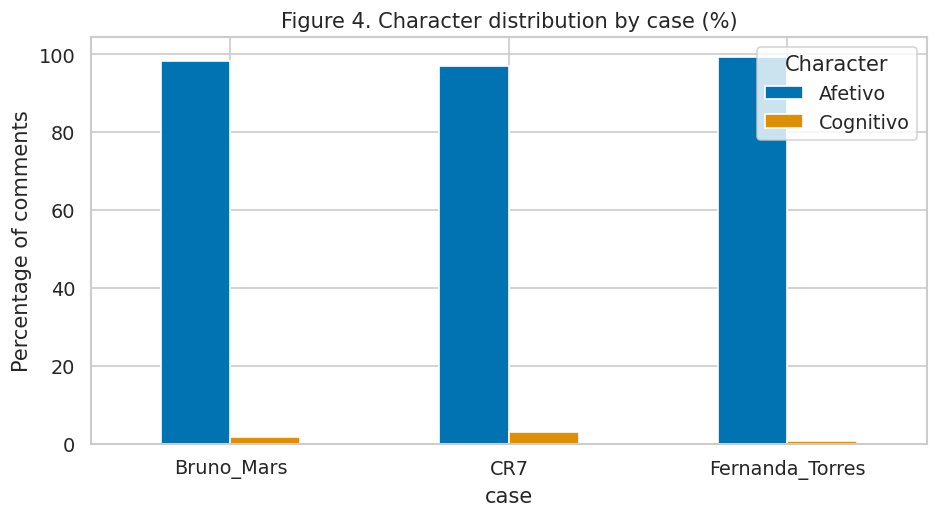

In [37]:
# Figure 4: character distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
char_pct.T.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Figure 4. Character distribution by case (%)")
ax.set_ylabel("Percentage of comments")
ax.legend(title="Character")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_character_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Tone analysis: positive, negative, neutral

Tone is coded as Positive, Negative, or Neutral, following the three-pole sentiment framework common in opinion mining (Pang & Lee, 2008) and adapted by Li and Feng (2022) for social-media comment analysis.

In [38]:
tone_crosstab = pd.crosstab(df["tone"], df["case"], margins=True, margins_name="Total")
tone_pct = pd.crosstab(df["tone"], df["case"], normalize="columns") * 100
print("Tone counts:")
display(tone_crosstab)
print("\nTone percentages by case:")
display(tone_pct.round(1))

Tone counts:


case,Bruno_Mars,CR7,Fernanda_Torres,Total
tone,,,,
Negativo,14,184,33,231
Neutro,128,142,48,318
Positivo,7958,2242,6538,16738
Total,8100,2568,6619,17287



Tone percentages by case:


case,Bruno_Mars,CR7,Fernanda_Torres
tone,,,
Negativo,0.2,7.2,0.5
Neutro,1.6,5.5,0.7
Positivo,98.2,87.3,98.8


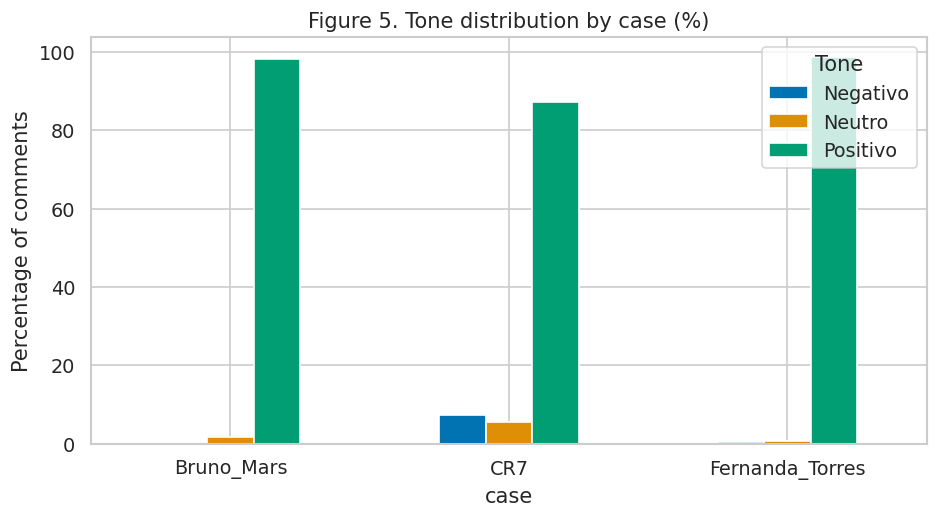

In [39]:
# Figure 5: tone distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
tone_pct.T.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Figure 5. Tone distribution by case (%)")
ax.set_ylabel("Percentage of comments")
ax.legend(title="Tone")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_tone_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Stakeholder analysis

The methodology proposes classifying the comment author as one of four stakeholder types (Garay, 2019; Li, Johnston & Feng, 2024): (a) ordinary user, (b) celebrity/influencer, (c) media outlet, or (d) brand/company.

**Note:** The dataset was anonymized during ethical preprocessing, so no username or follower-count field is available. Therefore, stakeholder classification cannot be performed on the current corpus. If author metadata is recovered later, this section can be enabled by adding a `stakeholder` column.

In [40]:
stakeholder_available = "stakeholder" in df.columns
print(f"Stakeholder column available: {stakeholder_available}")
if stakeholder_available:
    display(pd.crosstab(df["stakeholder"], df["case"], margins=True))
else:
    print("Skipping stakeholder analysis: author metadata not present in anonymized dataset.")

Stakeholder column available: False
Skipping stakeholder analysis: author metadata not present in anonymized dataset.


## 7. Non-verbal elements: emojis and hashtags

Emojis function as paralinguistic cues that signal affiliation, affect, or irony in digitally mediated interaction (Marwick & boyd, 2011). We count and visualize the most frequent emojis per case. Hashtags are also counted when present.

In [41]:
def parse_list_column(value):
    """Parse a column stored as string representation of a list."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text.startswith("[") and text.endswith("]"):
        try:
            return ast.literal_eval(text)
        except (SyntaxError, ValueError):
            pass
    return []


df["emojis_parsed"] = df["emojis_list"].apply(parse_list_column)
df["hashtags_parsed"] = df["hashtags_list"].apply(parse_list_column)

# Top emojis per case
top_emojis = {}
for case in sorted(df["case"].unique()):
    emojis = df.loc[df["case"] == case, "emojis_parsed"].explode()
    top_emojis[case] = emojis.value_counts().head(10)
    print(f"\nTop emojis for {case}:")
    print(top_emojis[case])


Top emojis for Bruno_Mars:
emojis_parsed
🇧🇷    5801
💚     1952
💛     1500
❤️    1473
🔥     1411
😍     1374
📍     1274
😂     1022
🎉       26
🥳       26
Name: count, dtype: int64

Top emojis for CR7:
emojis_parsed
❤️    688
😢     421
👏     379
🔥     227
🙌     188
😍     147
🐐     101
🙏      86
🇧🇷     65
💔      58
Name: count, dtype: int64

Top emojis for Fernanda_Torres:
emojis_parsed
🇧🇷    3492
❤️    2080
🏆     1526
😍      693
👏      650
✨      475
🔥      286
🙌      140
💚       89
💛       59
Name: count, dtype: int64


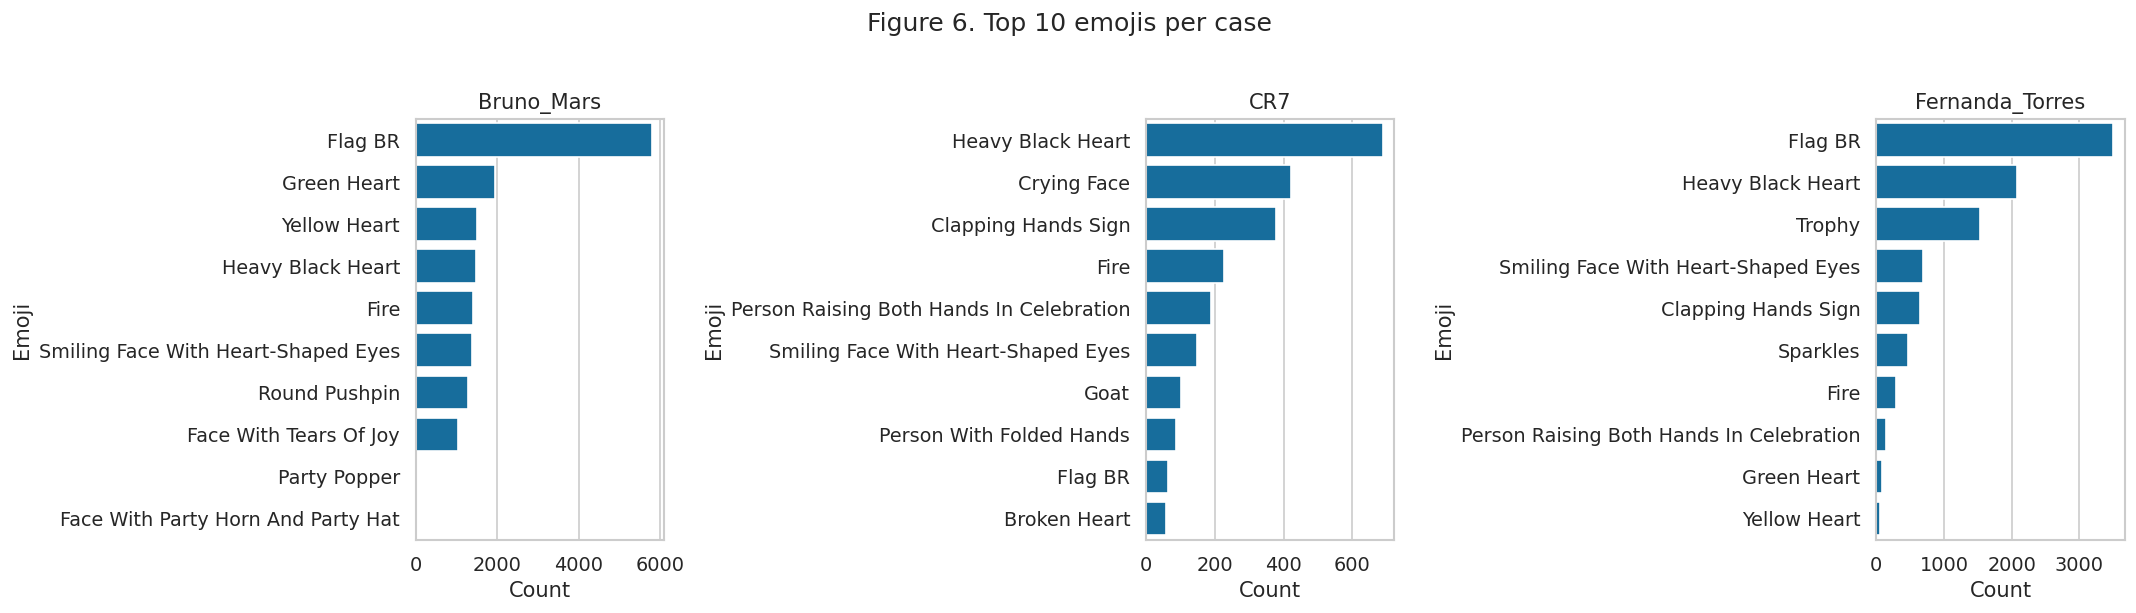

In [42]:
# Figure 6: top emojis per case
# DejaVu Sans (matplotlib default) has no emoji glyphs; Apple Color Emoji is
# not usable as a matplotlib text font. Use Unicode names as tick labels.


def emoji_display_name(emoji: str) -> str:
    """Return a readable Unicode name for an emoji (flag-aware)."""
    chars = list(emoji)
    regional = [c for c in chars if 0x1F1E6 <= ord(c) <= 0x1F1FF]
    if len(regional) >= 2:
        code = "".join(chr(ord(c) - 0x1F1E6 + ord("A")) for c in regional[:2])
        return f"Flag {code}"
    names = []
    for ch in chars:
        try:
            name = unicodedata.name(ch).replace("_", " ").title()
        except ValueError:
            continue
        if "Variation Selector" in name or "Zero Width" in name:
            continue
        names.append(name)
    return " + ".join(names) if names else repr(emoji)


cases = sorted(df["case"].unique())
fig, axes = plt.subplots(1, len(cases), figsize=(18, 5), sharey=False)
if len(cases) == 1:
    axes = [axes]
for ax, case in zip(axes, cases, strict=True):
    data = top_emojis[case].reset_index()
    data.columns = ["emoji", "count"]
    data["label"] = data["emoji"].map(emoji_display_name)
    sns.barplot(data=data, y="label", x="count", ax=ax, orient="h")
    ax.set_title(case)
    ax.set_xlabel("Count")
    ax.set_ylabel("Emoji")
fig.suptitle("Figure 6. Top 10 emojis per case", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_top_emojis.png", dpi=300, bbox_inches="tight")
plt.show()

# #region agent log
with open(".cursor/debug-f05939.log", "a") as _f:
    _f.write(
        __import__("json").dumps(
            {
                "sessionId": "f05939",
                "runId": "post-fix",
                "hypothesisId": "H1",
                "location": "analysis.ipynb:cell22",
                "message": "emoji labels used",
                "data": {
                    "sample_labels": {
                        case: top_emojis[case].index.map(emoji_display_name).tolist()[:5]
                        for case in cases
                    }
                },
                "timestamp": int(__import__("time").time() * 1000),
            },
            ensure_ascii=False,
        )
        + "\n"
    )
# #endregion

In [43]:
# Hashtag summary
hashtag_counts = df["hashtags_parsed"].apply(len)
n_with_hashtag = int((hashtag_counts > 0).sum())
pct_with_hashtag = float((hashtag_counts > 0).mean())
print(f"Comments with at least one hashtag: {n_with_hashtag} ({pct_with_hashtag:.2%})")

if n_with_hashtag > 0:
    all_hashtags = df["hashtags_parsed"].explode().value_counts().head(20)
    print("\nTop hashtags:")
    print(all_hashtags)
else:
    print("No hashtags available for analysis.")

Comments with at least one hashtag: 674 (3.90%)

Top hashtags:
hashtags_parsed
#rumoaos200m           376
#rumoaos200M           236
#imstillhere            14
#aindaestouaqui         12
#fernandatorres         10
#theperamesedsavior      5
#200M                    3
#ImStillHere             3
#oscars                  2
#oscar2025               2
#bruninhoquarentou       1
#rumo                    1
#sdds                    1
#rumosaos200M            1
#BRUNINHO                1
#ComeToVizag             1
#BrunoMarsInIndia        1
#BeachConcert            1
#250M                    1
#brunao                  1
Name: count, dtype: int64


## 8. Word-frequency analysis and word clouds

Word clouds visualize the most recurrent terms and conversation foci (Garay, 2019). We preprocess Portuguese text by lowercasing, removing punctuation, and filtering stopwords.

In [44]:
PORTUGUESE_STOPWORDS = {
    "a",
    "ao",
    "aos",
    "aquela",
    "aquelas",
    "aquele",
    "aqueles",
    "aquilo",
    "as",
    "até",
    "com",
    "como",
    "da",
    "das",
    "de",
    "dela",
    "delas",
    "dele",
    "deles",
    "depois",
    "do",
    "dos",
    "e",
    "ela",
    "elas",
    "ele",
    "eles",
    "em",
    "entre",
    "era",
    "eram",
    "essa",
    "essas",
    "esse",
    "esses",
    "esta",
    "estamos",
    "estas",
    "estava",
    "estavam",
    "este",
    "esteja",
    "estejam",
    "estejamos",
    "estes",
    "esteve",
    "estive",
    "estivemos",
    "estiver",
    "estiveram",
    "estiverem",
    "estivermos",
    "estivesse",
    "estivessem",
    "estivéramos",
    "estivéssemos",
    "estou",
    "eu",
    "foi",
    "fomos",
    "for",
    "fora",
    "foram",
    "forem",
    "formos",
    "fosse",
    "fossem",
    "fostes",
    "fui",
    "há",
    "isso",
    "isto",
    "já",
    "lhe",
    "lhes",
    "mais",
    "mas",
    "me",
    "mesmo",
    "meu",
    "meus",
    "minha",
    "minhas",
    "muito",
    "na",
    "nas",
    "no",
    "nos",
    "nossa",
    "nossas",
    "nosso",
    "nossos",
    "num",
    "numa",
    "não",
    "o",
    "os",
    "ou",
    "para",
    "pela",
    "pelas",
    "pelo",
    "pelos",
    "por",
    "qual",
    "quando",
    "que",
    "quem",
    "se",
    "sea",
    "seja",
    "sejam",
    "sejamos",
    "sem",
    "ser",
    "será",
    "serão",
    "serei",
    "seremos",
    "seria",
    "seriam",
    "seríamos",
    "seu",
    "seus",
    "somos",
    "sou",
    "sua",
    "suas",
    "também",
    "te",
    "tem",
    "temos",
    "tenha",
    "tenham",
    "tenhamos",
    "tenho",
    "ter",
    "terá",
    "terão",
    "terei",
    "teremos",
    "teria",
    "teriam",
    "teríamos",
    "teu",
    "teus",
    "teve",
    "tinha",
    "tinham",
    "tive",
    "tivemos",
    "tiver",
    "tiveram",
    "tiverem",
    "tivermos",
    "tivesse",
    "tivessem",
    "tivéramos",
    "tivéssemos",
    "tu",
    "tua",
    "tuas",
    "um",
    "uma",
    "você",
    "vocês",
    "vos",
    "à",
    "às",
    "é",
    "éramos",
}

ENGLISH_STOPWORDS = {
    "a",
    "about",
    "above",
    "after",
    "again",
    "against",
    "all",
    "am",
    "an",
    "and",
    "any",
    "are",
    "as",
    "at",
    "be",
    "because",
    "been",
    "before",
    "being",
    "below",
    "between",
    "both",
    "but",
    "by",
    "can",
    "could",
    "did",
    "do",
    "does",
    "doing",
    "don",
    "down",
    "during",
    "each",
    "few",
    "for",
    "from",
    "further",
    "had",
    "has",
    "have",
    "having",
    "he",
    "her",
    "here",
    "hers",
    "herself",
    "him",
    "himself",
    "his",
    "how",
    "i",
    "if",
    "in",
    "into",
    "is",
    "it",
    "its",
    "itself",
    "just",
    "me",
    "more",
    "most",
    "my",
    "myself",
    "no",
    "nor",
    "not",
    "now",
    "of",
    "off",
    "on",
    "once",
    "only",
    "or",
    "other",
    "our",
    "ours",
    "ourselves",
    "out",
    "over",
    "own",
    "same",
    "she",
    "should",
    "so",
    "some",
    "such",
    "than",
    "that",
    "the",
    "their",
    "theirs",
    "them",
    "themselves",
    "then",
    "there",
    "these",
    "they",
    "this",
    "those",
    "through",
    "to",
    "too",
    "under",
    "until",
    "up",
    "very",
    "was",
    "we",
    "were",
    "what",
    "when",
    "where",
    "which",
    "while",
    "who",
    "whom",
    "why",
    "will",
    "with",
    "would",
    "you",
    "your",
    "yours",
    "yourself",
    "yourselves",
    "im",
    "dont",
    "didnt",
    "cant",
    "wont",
    "youre",
    "thats",
    "heres",
    "theres",
    "ive",
    "ill",
    "id",
    "lets",
    "isnt",
    "arent",
    "wasnt",
    "werent",
    "hasnt",
    "havent",
    "hadnt",
    "doesnt",
    "wouldnt",
    "couldnt",
    "shouldnt",
}

STOPWORDS = PORTUGUESE_STOPWORDS | ENGLISH_STOPWORDS


def tokenize_pt(text):
    """Simple Portuguese/English tokenizer for word-frequency analysis."""
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)  # remove mentions
    text = re.sub(r"[^\w\s]", " ", text)
    tokens = [t.strip(string.punctuation) for t in text.split() if t.strip()]
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens


df["tokens"] = df["comment_anon"].apply(tokenize_pt)

# Top words per case
for case in sorted(df["case"].unique()):
    words = df.loc[df["case"] == case, "tokens"].explode()
    top = words.value_counts().head(15)
    print(f"\nTop words for {case}:")
    print(top)

# #region agent log
with open(".cursor/debug-f05939.log", "a") as _f:
    _cr7 = df.loc[df["case"] == "CR7", "tokens"].explode().value_counts().head(15)
    _en_hit = [w for w in _cr7.index if w in ENGLISH_STOPWORDS]
    _f.write(
        __import__("json").dumps(
            {
                "sessionId": "f05939",
                "runId": "post-fix",
                "hypothesisId": "H2",
                "location": "analysis.ipynb:cell25",
                "message": "CR7 top after EN+PT stopwords",
                "data": {
                    "top15": {str(k): int(v) for k, v in _cr7.items()},
                    "english_stopwords_in_top": _en_hit,
                },
                "timestamp": int(__import__("time").time() * 1000),
            },
            ensure_ascii=False,
        )
        + "\n"
    )
# #endregion


Top words for Bruno_Mars:
tokens
rumoaos200m    613
bruninho       324
brasil         166
come            82
volta           79
bora            67
aqui            60
happy           56
bruno           54
pra             52
200             50
birthday        49
brazil          48
feliz           45
milhões         40
Name: count, dtype: int64

Top words for CR7:
tokens
pele         77
ronaldo      65
rip          61
rei          49
pelé         48
legend       42
goat         35
cristiano    32
god          31
two          31
king         25
love         25
cr7          23
mundo        22
best         21
Name: count, dtype: int64

Top words for Fernanda_Torres:
tokens
fernanda       281
aqui           231
maravilhosa    196
oscar          186
ainda          162
brasil         156
torres         141
melhor         140
best           138
queen           98
pra             95
vai             84
diva            84
maior           79
winner          63
Name: count, dtype: int64


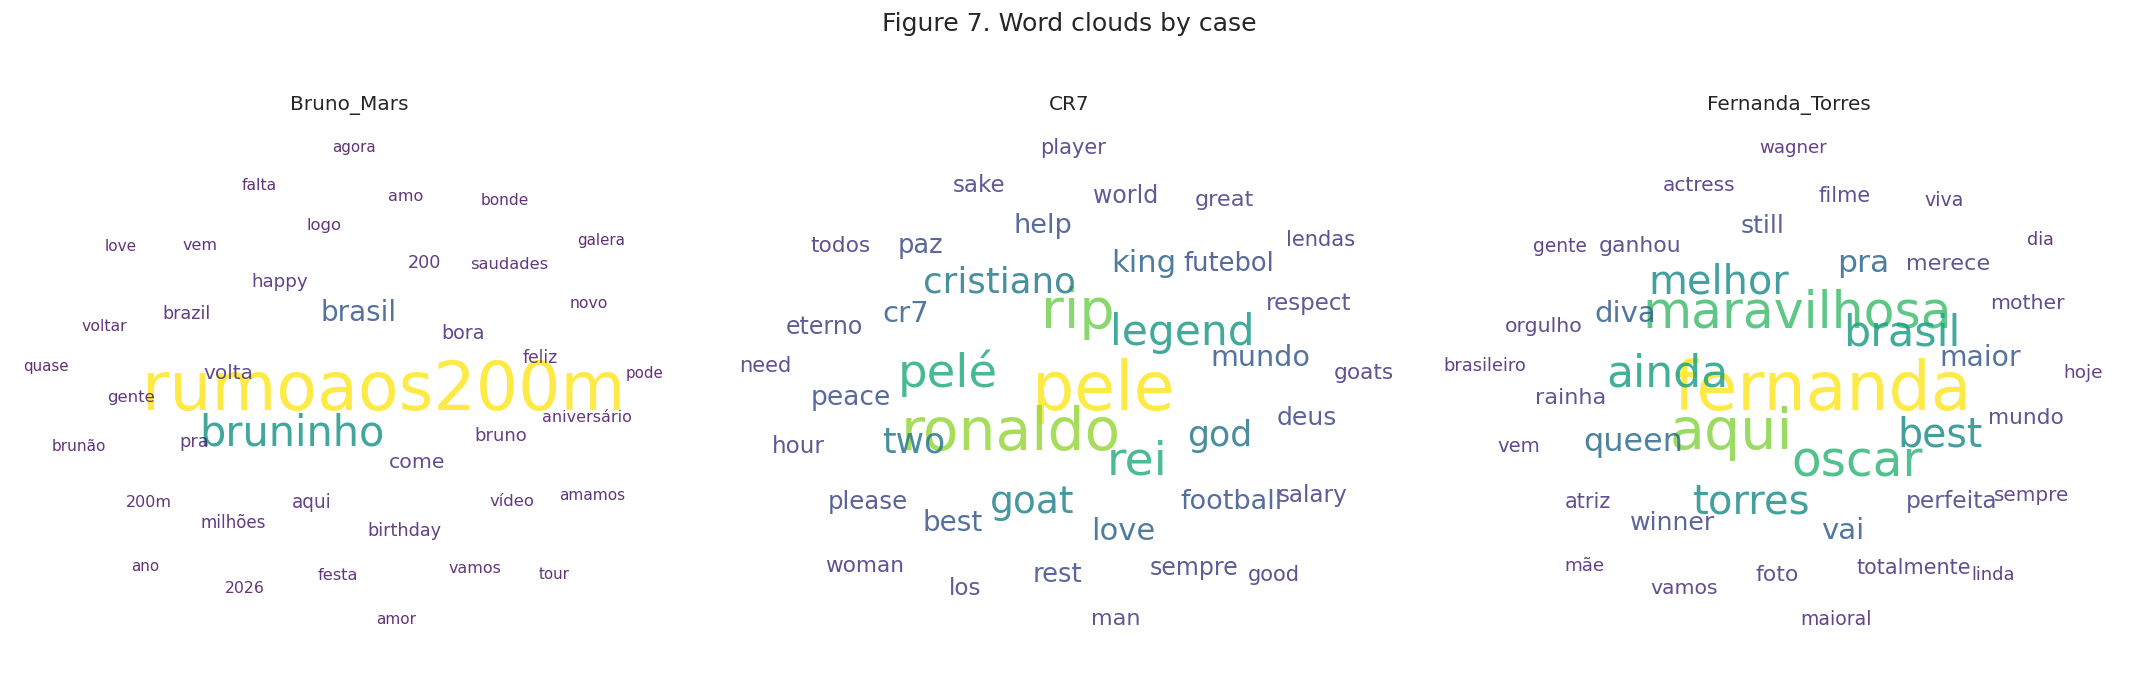

In [45]:
# Simple word-cloud layout using matplotlib (no external wordcloud dependency)
def draw_wordcloud(words_series, title, ax, max_words=40):
    """Draw a word cloud from a pandas Series of word counts."""
    counts = words_series.value_counts().head(max_words)
    if counts.empty:
        ax.text(0.5, 0.5, "No words", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        return
    np.random.seed(42)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=12)
    max_count = counts.max()
    # Spiral-like placement
    for i, (word, count) in enumerate(counts.items()):
        size = 8 + 32 * (count / max_count)
        angle = 2 * np.pi * i * 0.618
        radius = 0.05 + 0.42 * np.sqrt(i / max(len(counts), 1))
        x = 0.5 + radius * np.cos(angle)
        y = 0.5 + radius * np.sin(angle)
        # Keep inside bounds
        x = np.clip(x, 0.05, 0.95)
        y = np.clip(y, 0.05, 0.95)
        ax.text(
            x,
            y,
            word,
            fontsize=size,
            ha="center",
            va="center",
            color=plt.cm.viridis(count / max_count),
            alpha=0.85,
        )


fig, axes = plt.subplots(1, len(cases), figsize=(18, 5.5))
if len(cases) == 1:
    axes = [axes]
for ax, case in zip(axes, cases, strict=True):
    words = df.loc[df["case"] == case, "tokens"].explode()
    draw_wordcloud(words, case, ax)
fig.suptitle("Figure 7. Word clouds by case", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_wordclouds.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Statistical associations

To test whether themes, character, and tone are associated with case, we use Pearson's chi-square test of independence (Krippendorff, 2018). Cramér's V (Cramér, 1946) reports the strength of association on a 0–1 scale.

In [46]:
def cramers_v(chi2, n, r, k):
    """Compute Cramér's V from chi-square statistic and table dimensions."""
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))


def test_association(df, var, label):
    """Chi-square test of independence between case and a categorical variable."""
    contingency = pd.crosstab(df["case"], df[var])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    v = cramers_v(chi2, n, *contingency.shape)
    return {
        "variable": label,
        "chi2": round(chi2, 3),
        "df": dof,
        "p_value": p,
        "cramers_v": round(v, 3),
    }


stats_results = []
for col, code in zip(theme_cols, THEME_CODES + ["NA"], strict=True):
    stats_results.append(test_association(df, col, f"theme_{code}"))
stats_results.append(test_association(df, "character", "character"))
stats_results.append(test_association(df, "tone", "tone"))

stats_df = pd.DataFrame(stats_results)
stats_df["significant_05"] = stats_df["p_value"] < 0.05
stats_df["p_value"] = stats_df["p_value"].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
print(stats_df)

    variable       chi2  df    p_value  cramers_v  significant_05
0   theme_C1  13957.546   2   0.00e+00      0.899            True
1   theme_C2      3.061   2     0.2164      0.013           False
2   theme_C3     44.956   2   1.73e-10      0.051            True
3   theme_C4   7249.440   2   0.00e+00      0.648            True
4   theme_C5  10884.417   2   0.00e+00      0.793            True
5   theme_NA    384.131   2   3.86e-84      0.149            True
6  character     83.620   2   6.95e-19      0.070            True
7       tone   1035.799   4  6.23e-223      0.173            True


## 10. Validation of research propositions

The four propositions (P1–P4) are operationalized through the theme and tone distributions.

- **P1** (humor, national exaltation, validation): supported by high prevalence of C1, C2, and C4.
- **P2** (emotional factors of pride and belonging): supported by high share of *Afetivo* character and *Positivo* tone.
- **P3** (authenticity of UGC): the corpus is entirely user-generated, so the analysis reports source authenticity descriptively.
- **P4** (complexo de vira-lata): examined through the co-occurrence of C1 (nationalism) and C4 (validation/foreign affection) within comments and cases.

In [47]:
# P1: prevalence of C1, C2, C4
p1_cols = ["theme_C1", "theme_C2", "theme_C4"]
p1_pct = df.groupby("case")[p1_cols].mean() * 100
print("P1 indicators — theme prevalence by case (%):")
print(p1_pct.round(1))

# P2: affective and positive tone
p2_char = pd.crosstab(df["case"], df["character"], normalize="index") * 100
p2_tone = pd.crosstab(df["case"], df["tone"], normalize="index") * 100
print("\nP2 indicators — character by case (%):")
print(p2_char.round(1))
print("\nP2 indicators — tone by case (%):")
print(p2_tone.round(1))

# P4: co-occurrence of C1 and C4 (nationalism + validation)
df["C1_and_C4"] = (df["theme_C1"] == 1) & (df["theme_C4"] == 1)
p4_cooc = df.groupby("case")["C1_and_C4"].agg(["sum", "mean"]).reset_index()
p4_cooc["mean_pct"] = (p4_cooc["mean"] * 100).round(2)
print("\nP4 indicator — comments with both C1 and C4:")
print(p4_cooc[["case", "sum", "mean_pct"]])

P1 indicators — theme prevalence by case (%):
                 theme_C1  theme_C2  theme_C4
case                                         
Bruno_Mars            1.6       0.5      66.2
CR7                  36.7       0.2      63.6
Fernanda_Torres      98.5       0.5       0.2

P2 indicators — character by case (%):
character        Afetivo  Cognitivo
case                               
Bruno_Mars          98.3        1.7
CR7                 96.9        3.1
Fernanda_Torres     99.4        0.6

P2 indicators — tone by case (%):
tone             Negativo  Neutro  Positivo
case                                       
Bruno_Mars            0.2     1.6      98.2
CR7                   7.2     5.5      87.3
Fernanda_Torres       0.5     0.7      98.8

P4 indicator — comments with both C1 and C4:
              case  sum  mean_pct
0       Bruno_Mars   49      0.60
1              CR7  189      7.36
2  Fernanda_Torres    7      0.11


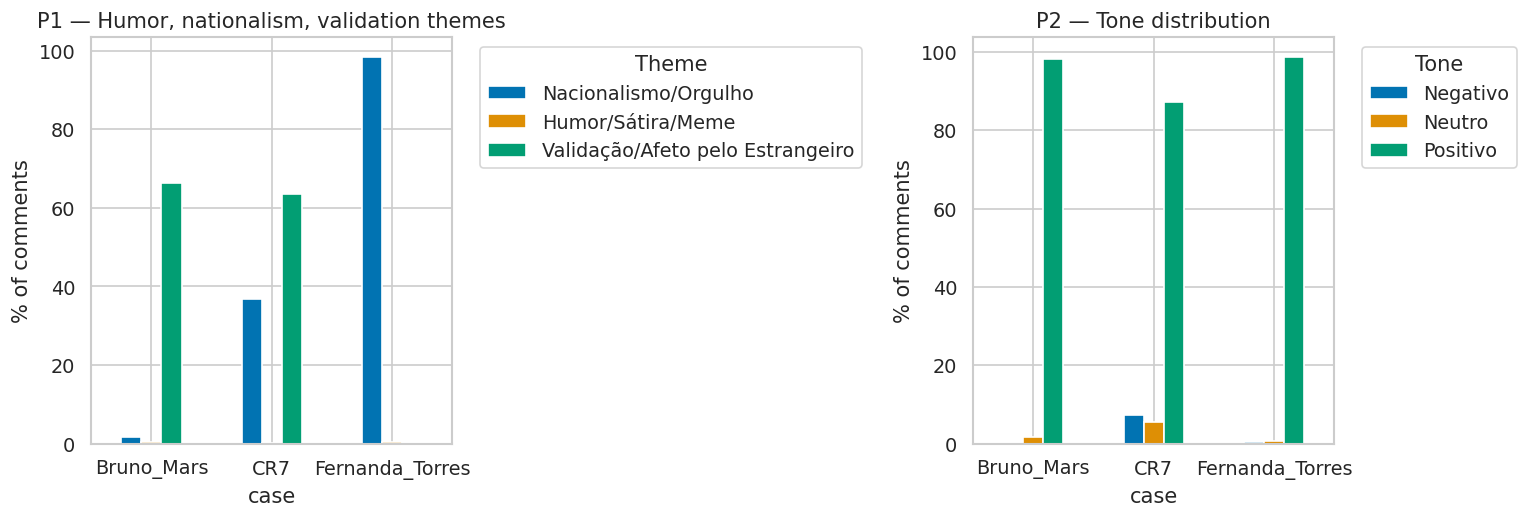

In [48]:
# Figure 8: proposition indicators
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

p1_plot = p1_pct.rename(columns={f"theme_{c}": THEME_LABELS[c] for c in ["C1", "C2", "C4"]})
p1_plot.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("P1 — Humor, nationalism, validation themes")
axes[0].set_ylabel("% of comments")
axes[0].legend(title="Theme", bbox_to_anchor=(1.05, 1), loc="upper left")

p2_tone.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("P2 — Tone distribution")
axes[1].set_ylabel("% of comments")
axes[1].legend(title="Tone", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_proposition_indicators.png", dpi=300, bbox_inches="tight")
plt.show()

# #region agent log
with open(".cursor/debug-f05939.log", "a") as _f:
    _f.write(
        __import__("json").dumps(
            {
                "sessionId": "f05939",
                "runId": "post-fix",
                "hypothesisId": "H3",
                "location": "analysis.ipynb:cell31",
                "message": "p1 legend labels",
                "data": {"columns": list(p1_plot.columns)},
                "timestamp": int(__import__("time").time() * 1000),
            },
            ensure_ascii=False,
        )
        + "\n"
    )
# #endregion

## 11. Human-review impact

We quantify the footprint of human adjudication. Comments enter the human-review queue when the reviewer model disagrees substantially with both coders (κ < 0.80). The adjudicated rows receive `classification_source = human` and `human_reviewed = True`.

In [49]:
n_human = df["human_reviewed"].sum()
print(f"Human-reviewed rows: {n_human} ({n_human / len(df):.1%})")
print("\nHuman-reviewed rows by case:")
print(df.loc[df["human_reviewed"], "case"].value_counts())

source_counts = df["classification_source"].value_counts()
print("\nClassification source distribution:")
print(source_counts)

# Theme changes after human review (if reviewer columns exist)
rev_cols = [f"theme_{c}_rev" for c in THEME_CODES] + ["theme_NA_rev"]
available_rev_cols = [c for c in rev_cols if c in df.columns]
if len(available_rev_cols) == len(theme_cols):
    changes = {}
    for final_col, rev_col in zip(theme_cols, available_rev_cols, strict=True):
        diff = (
            df.loc[df["human_reviewed"], final_col] != df.loc[df["human_reviewed"], rev_col]
        ).sum()
        changes[final_col] = diff
    print("\nTheme changes after human adjudication:")
    print(pd.Series(changes))

Human-reviewed rows: 188 (1.1%)

Human-reviewed rows by case:
case
CR7                102
Bruno_Mars          54
Fernanda_Torres     32
Name: count, dtype: int64

Classification source distribution:
classification_source
rule            11927
llm_agreed       3820
llm_reviewer     1352
human             188
Name: count, dtype: int64


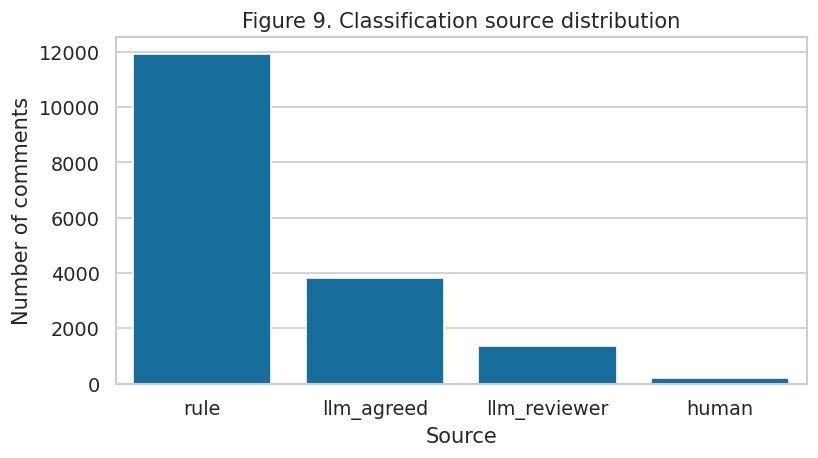

In [50]:
# Figure 9: classification source
plt.figure(figsize=(7, 4))
sns.barplot(x=source_counts.index, y=source_counts.values)
plt.title("Figure 9. Classification source distribution")
plt.ylabel("Number of comments")
plt.xlabel("Source")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_classification_source.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Final summary table (Tabela 1)

This table reproduces the structure proposed in the methodology document: absolute frequencies (N) and relative frequencies (%) for each category by case, plus the total. Stakeholder and hashtag rows are omitted because the required fields are not available in the anonymized dataset.

In [51]:
def build_final_table(df, case_totals):
    """Build Tabela 1 with N and % columns per case."""
    rows = []
    # Themes
    for code in THEME_CODES:
        col = f"theme_{code}"
        counts = df.groupby("case")[col].sum()
        row = {"Categoria": THEME_LABELS[code]}
        total_n = 0
        for case in case_totals.index:
            n = int(counts.get(case, 0))
            row[f"{case}_N"] = n
            row[f"{case}_%"] = f"{n / case_totals[case] * 100:.1f}%"
            total_n += n
        row["Total_N"] = total_n
        rows.append(row)
    # NA
    counts_na = df.groupby("case")["theme_NA"].sum()
    row_na = {"Categoria": "N.A."}
    total_na = 0
    for case in case_totals.index:
        n = int(counts_na.get(case, 0))
        row_na[f"{case}_N"] = n
        row_na[f"{case}_%"] = f"{n / case_totals[case] * 100:.1f}%"
        total_na += n
    row_na["Total_N"] = total_na
    rows.append(row_na)
    return pd.DataFrame(rows).set_index("Categoria")


theme_table = build_final_table(df, case_totals)
print("THEME table:")
display(theme_table)

THEME table:


,Bruno_Mars_N,Bruno_Mars_%,Fernanda_Torres_N,Fernanda_Torres_%,CR7_N,CR7_%,Total_N
Categoria,,,,,,,
Nacionalismo/Orgulho,127,1.6%,6519,98.5%,942,36.7%,7588
Humor/Sátira/Meme,40,0.5%,30,0.5%,6,0.2%,76
Conflito/Rivalidade,3,0.0%,29,0.4%,21,0.8%,53
Validação/Afeto pelo Estrangeiro,5364,66.2%,13,0.2%,1632,63.6%,7009
Apropriação do Espaço Digital,6657,82.2%,304,4.6%,71,2.8%,7032
N.A.,28,0.3%,46,0.7%,128,5.0%,202


In [52]:
# Character table
char_n = pd.crosstab(df["character"], df["case"], margins=True, margins_name="Total")
char_pct_table = pd.crosstab(df["character"], df["case"], normalize="columns") * 100
char_table = pd.DataFrame(index=char_n.index)
for case in char_n.columns:
    if case == "Total":
        char_table["Total_N"] = char_n[case]
    else:
        char_table[f"{case}_N"] = char_n[case]
        pct = char_pct_table[case].reindex(char_n.index)
        pct.loc["Total"] = 100.0
        char_table[f"{case}_%"] = pct.round(1).astype(str) + "%"
char_table.index.name = "CARÁTER"
print("CHARACTER table:")
display(char_table)

CHARACTER table:


,Bruno_Mars_N,Bruno_Mars_%,CR7_N,CR7_%,Fernanda_Torres_N,Fernanda_Torres_%,Total_N
CARÁTER,,,,,,,
Afetivo,7961,98.3%,2489,96.9%,6580,99.4%,17030
Cognitivo,139,1.7%,79,3.1%,39,0.6%,257
Total,8100,100.0%,2568,100.0%,6619,100.0%,17287


In [53]:
# Tone table
tone_n = pd.crosstab(df["tone"], df["case"], margins=True, margins_name="Total")
tone_pct_table = pd.crosstab(df["tone"], df["case"], normalize="columns") * 100
tone_table = pd.DataFrame(index=tone_n.index)
for case in tone_n.columns:
    if case == "Total":
        tone_table["Total_N"] = tone_n[case]
    else:
        tone_table[f"{case}_N"] = tone_n[case]
        pct = tone_pct_table[case].reindex(tone_n.index)
        pct.loc["Total"] = 100.0
        tone_table[f"{case}_%"] = pct.round(1).astype(str) + "%"
tone_table.index.name = "TOM (SENTIMENTO)"
print("TONE table:")
display(tone_table)

TONE table:


,Bruno_Mars_N,Bruno_Mars_%,CR7_N,CR7_%,Fernanda_Torres_N,Fernanda_Torres_%,Total_N
TOM (SENTIMENTO),,,,,,,
Negativo,14,0.2%,184,7.2%,33,0.5%,231
Neutro,128,1.6%,142,5.5%,48,0.7%,318
Positivo,7958,98.2%,2242,87.3%,6538,98.8%,16738
Total,8100,100.0%,2568,100.0%,6619,100.0%,17287


In [54]:
# Save combined final table
final_dataset = pd.concat(
    {"TEMA": theme_table, "CARÁTER": char_table, "TOM (SENTIMENTO)": tone_table}
)
final_dataset.to_csv("outputs/aggregates/final_dataset_human.csv")
print("Saved outputs/aggregates/final_dataset_human.csv")

Saved outputs/aggregates/final_dataset_human.csv


## 13. References

- Almeida, C. (2015). *Uma história do imaginário brasileiro: O brazil e o Brasil*. Companhia das Letras.
- Bardin, L. (2016). *Análise de conteúdo* (4th ed.). Edições 70.
- Bazi, V., & Fabbri, P. (2015). *Comunicação e identidade nacional: aspectos da cultura brasileira*. Intercom.
- boyd, d. (2014). [*It's complicated: The social lives of networked teens*](https://yalebooks.yale.edu/book/9780300166316/its-complicated). Yale University Press.
- Braun, V., & Clarke, V. (2006). [Using thematic analysis in psychology](https://doi.org/10.1191/1478088706qp063oa). *Qualitative Research in Psychology*, 3(2), 77–101.
- Chen, Y., & Gao, Q. (2022). *Social media and celebrity culture*. Routledge.
- Cohen, J. (1960). [A coefficient of agreement for nominal scales](https://doi.org/10.1177/001316446002000104). *Educational and Psychological Measurement*, 20(1), 37–46.
- Costa, C. (2020). *Fandoms brasileiros e a busca por reconhecimento internacional*. Annablume.
- Cramér, H. (1946). *Mathematical methods of statistics*. Princeton University Press.
- Dinnie, K. (2016). *Nation branding: Concepts, issues, practice* (2nd ed.). Routledge.
- Fontanella, B. J. B., Ricas, J., & Turato, E. R. (2011). Amostragem por saturação em pesquisas qualitativas em saúde: contribuições teóricas. *Cadernos de Saúde Pública*, 24(1), 17–27.
- Freeman, R. E. (2010). *Strategic management: A stakeholder approach*. Cambridge University Press.
- Garay, C. A. (2019). *Análise de conteúdo digital: métodos e técnicas*. Edições SESC.
- Gilardi, F., Alizadeh, M., & Kubli, M. (2023). [ChatGPT outperforms crowd workers for text-annotation tasks](https://doi.org/10.1073/pnas.2305016120). *PNAS*, 120(30), e2305016120.
- Kaplan, A. M., & Haenlein, M. (2010). [Users of the world, unite! The challenges and opportunities of social media](https://doi.org/10.1016/j.bushor.2009.09.003). *Business Horizons*, 53(1), 59–68.
- Kozinets, R. V. (2014). *Netnography: Redefined* (2nd ed.). SAGE.
- Landis, J. R., & Koch, G. G. (1977). [The measurement of observer agreement for categorical data](https://doi.org/10.2307/2529310). *Biometrics*, 33(1), 159–174.
- Lemes, S. (2024). *O rastro digital do Brasil: identidade nacional nas redes sociais*. FGV Editora.
- Li, X., Johnston, M. A., & Feng, T. (2024). Destination image on social media: a multi-stakeholder perspective. *Tourism Management*, 99, 104825.
- Li, X., & Feng, T. (2022). Sentiment in tourism user-generated content: A comparative study. *Annals of Tourism Research*, 94, 103413.
- Marwick, A., & boyd, d. (2011). [I tweet honestly, I tweet passionately: Twitter users, context collapse, and the imagined audience](https://doi.org/10.1177/1461444810365313). *New Media & Society*, 13(1), 114–133.
- Pang, B., & Lee, L. (2008). [Opinion mining and sentiment analysis](https://doi.org/10.1561/1500000011). *Foundations and Trends in Information Retrieval*, 2(1–2), 1–135.
- Sheen, A., Tung, S., & Wu, D. (2021). Credibility of government information on social media. *Government Information Quarterly*, 38(2), 101572.
- Tajfel, H., & Turner, J. C. (1979). [An integrative theory of intergroup conflict](https://doi.org/10.4324/9780203505984-16). In W. G. Austin & S. Worchel (Eds.), *The social psychology of intergroup relations* (pp. 33–47). Brooks/Cole.
- Wang, X., & Huang, Y. (2023). Digital influencers and identity performance. *New Media & Society*, 25(4), 892–911.